# Hyperparameter Tuning — Repair Cost

## Objective

Improve the performance of the selected Random Forest model by
searching for better hyperparameter combinations.

The baseline Random Forest from model selection will be used as
the reference model.

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [27]:
df = pd.read_csv("ml_ready.csv")
df.shape

(6583, 26)

In [28]:
X = df.drop(
    columns=[
        "Repair_Cost",
        "Turnaround_Time_Days",
        "Is_Delayed"
    ]
)

y = df["Repair_Cost"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

In [31]:
print("Numerical:", len(numerical_features))
print("Categorical:", len(categorical_features))

Numerical: 13
Categorical: 10


In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [33]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [34]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [35]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

In [36]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['Visit_Number',
                                                                                'Vehicle_Age_at_Service',
                                                                                'Battery_Age_at_Service',
                                                                                'Battery_Health_at_Service',
                                                                                'Expected_Part_ETA_Days',
                                                                                'Active_Jobs_On_Arrival',
                                                                                'Workshop_Utilization',
                                                                                'Technician_Experience_Years',
                                                                                'Repair_Complexity',
                                                                                'Base_Labor_Ho...
                                                                                'Part_Ordered',
                                                                                'Day_Type',
                                                                                'Warranty_Status',
                                                                                'Warranty_Covered'])])),
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [37]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 10}


In [38]:
print(
    f"Best CV MAE: {-random_search.best_score_:.2f}"
)

Best CV MAE: 293.13


In [39]:
best_model = random_search.best_estimator_

In [40]:
y_pred_tuned = best_model.predict(X_test)

In [41]:
mae_tuned = mean_absolute_error(
    y_test,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

r2_tuned = r2_score(
    y_test,
    y_pred_tuned
)

In [42]:
print(f"MAE  : {mae_tuned:.2f}")
print(f"RMSE : {rmse_tuned:.2f}")
print(f"R²   : {r2_tuned:.3f}")

MAE  : 294.56
RMSE : 627.43
R²   : 0.951


In [43]:
import joblib

joblib.dump(
    best_model,
    "repair_cost_model.pkl"
)

['repair_cost_model.pkl']

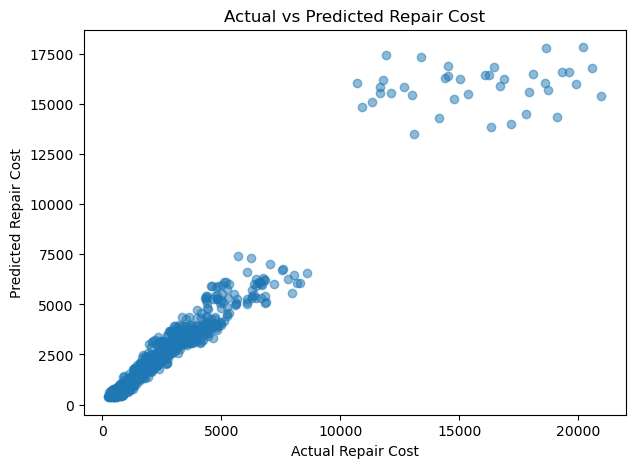

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.5
)

plt.xlabel("Actual Repair Cost")
plt.ylabel("Predicted Repair Cost")
plt.title("Actual vs Predicted Repair Cost")

plt.show()

In [20]:
rf_model = best_model.named_steps["model"]

In [21]:
preprocessor_fitted = best_model.named_steps["preprocessor"]

In [22]:
feature_names = preprocessor_fitted.get_feature_names_out()

In [23]:
importance = rf_model.feature_importances_

In [24]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
29,cat__Exact_Issue_Battery Degradation,0.571423
8,num__Repair_Complexity,0.105705
56,cat__Parts_Required_True,0.097225
55,cat__Parts_Required_False,0.088342
9,num__Base_Labor_Hours,0.082686
11,num__Effective_Labor_Hours,0.018654
3,num__Battery_Health_at_Service,0.004363
23,cat__Issue_Family_Electrical,0.003167
1,num__Vehicle_Age_at_Service,0.003003
34,cat__Exact_Issue_Brake Pad Wear,0.002556


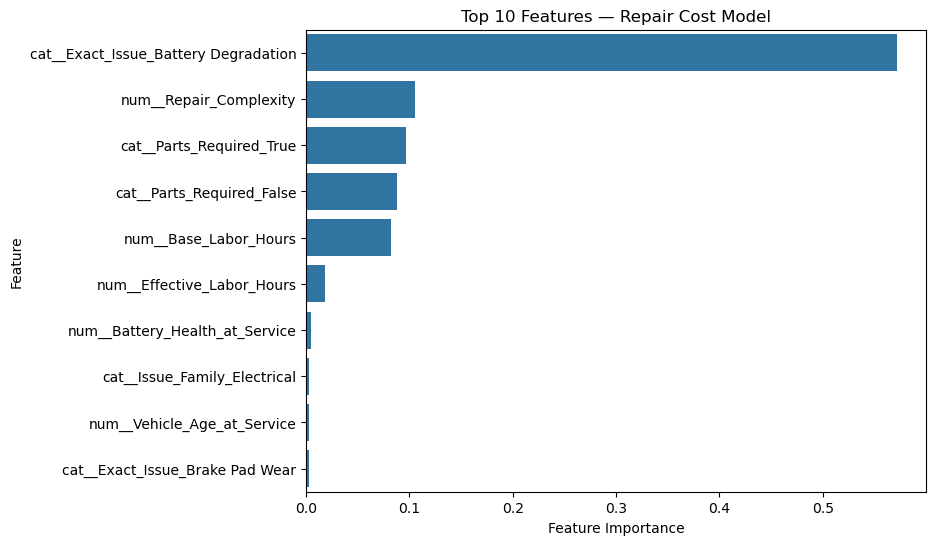

In [25]:
import seaborn as sns

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features — Repair Cost Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## Final Model Conclusion

Three regression models were evaluated for Repair Cost prediction:

- Linear Regression
- Decision Tree
- Random Forest

Random Forest performed best during model selection.

After hyperparameter tuning, the final model achieved:

- MAE: ₹294.56
- RMSE: ₹627.43
- R²: 0.951

The tuned Random Forest showed a modest improvement over the baseline
Random Forest, indicating that the baseline model was already strong.

Feature importance showed that exact issue, repair complexity,
parts requirement, and base labor hours were among the most important
predictive features.

These feature importance results indicate predictive usefulness and
should not be interpreted as causal relationships.